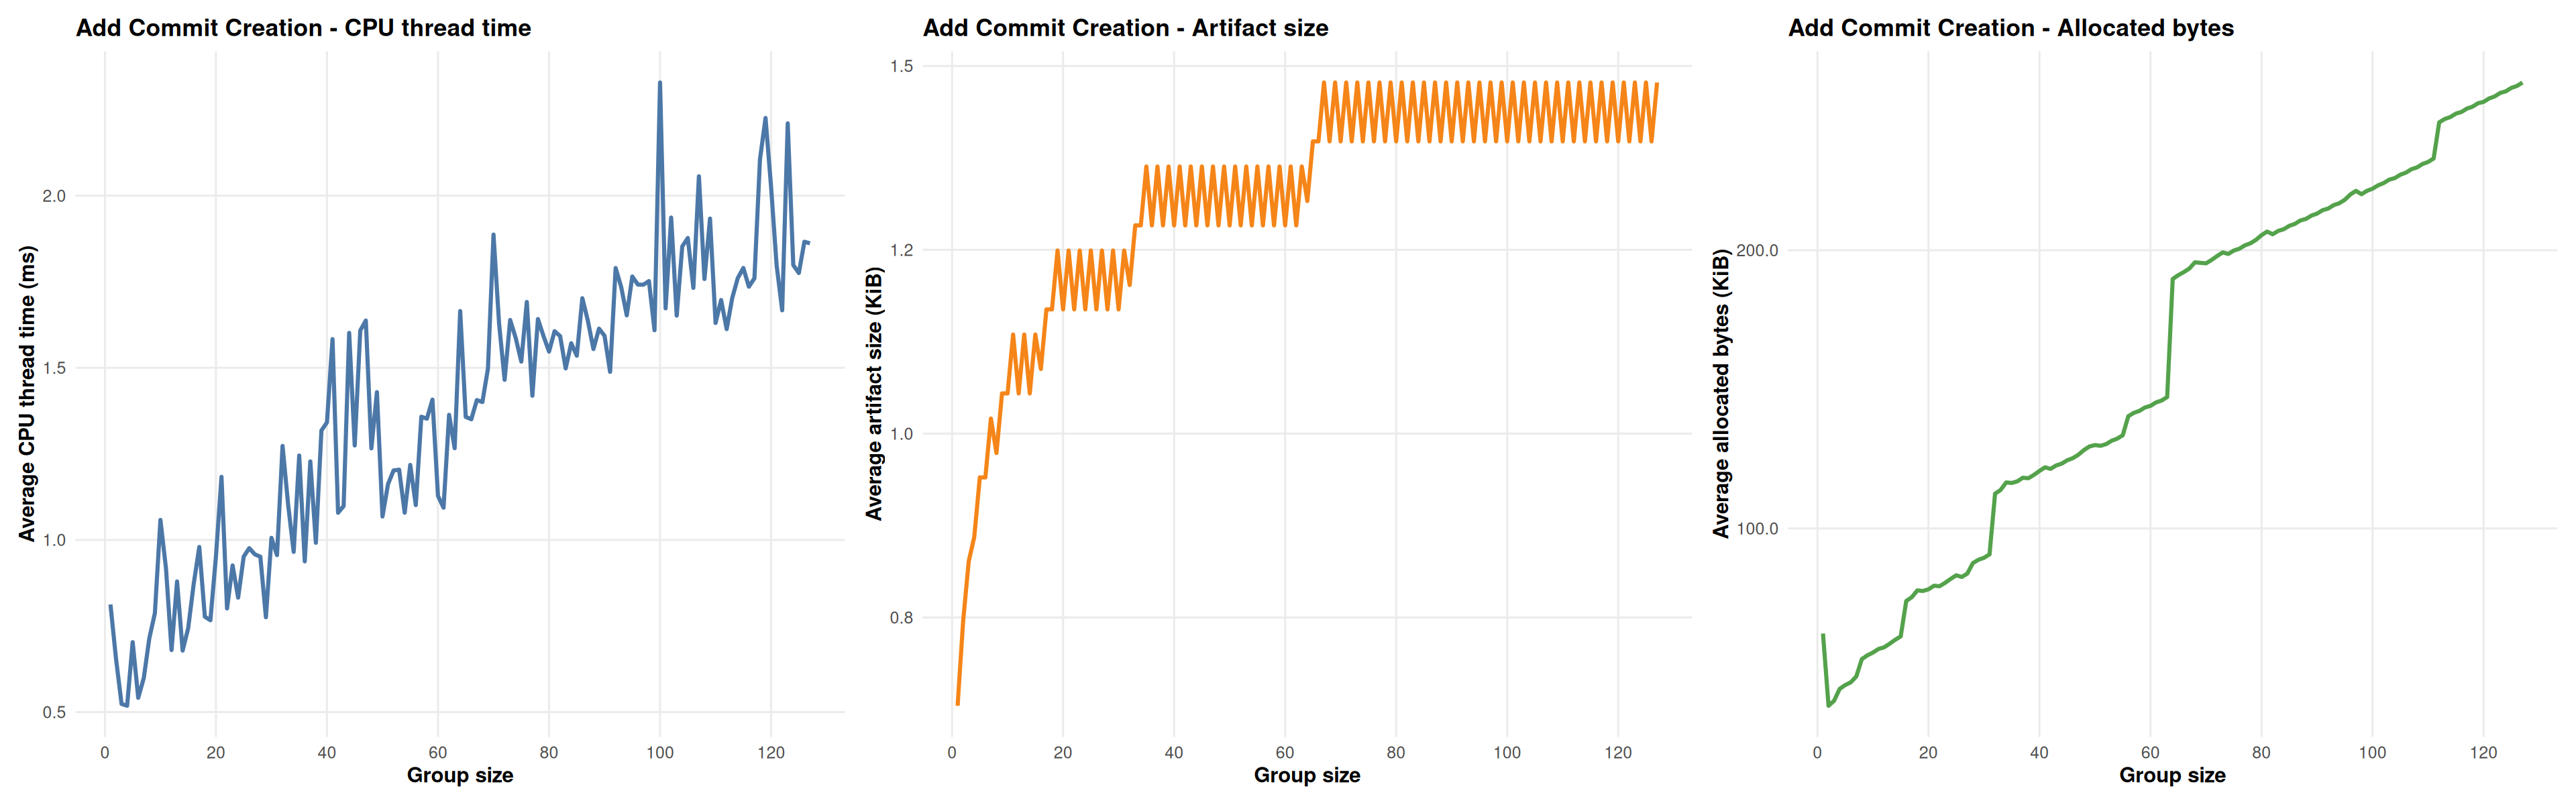

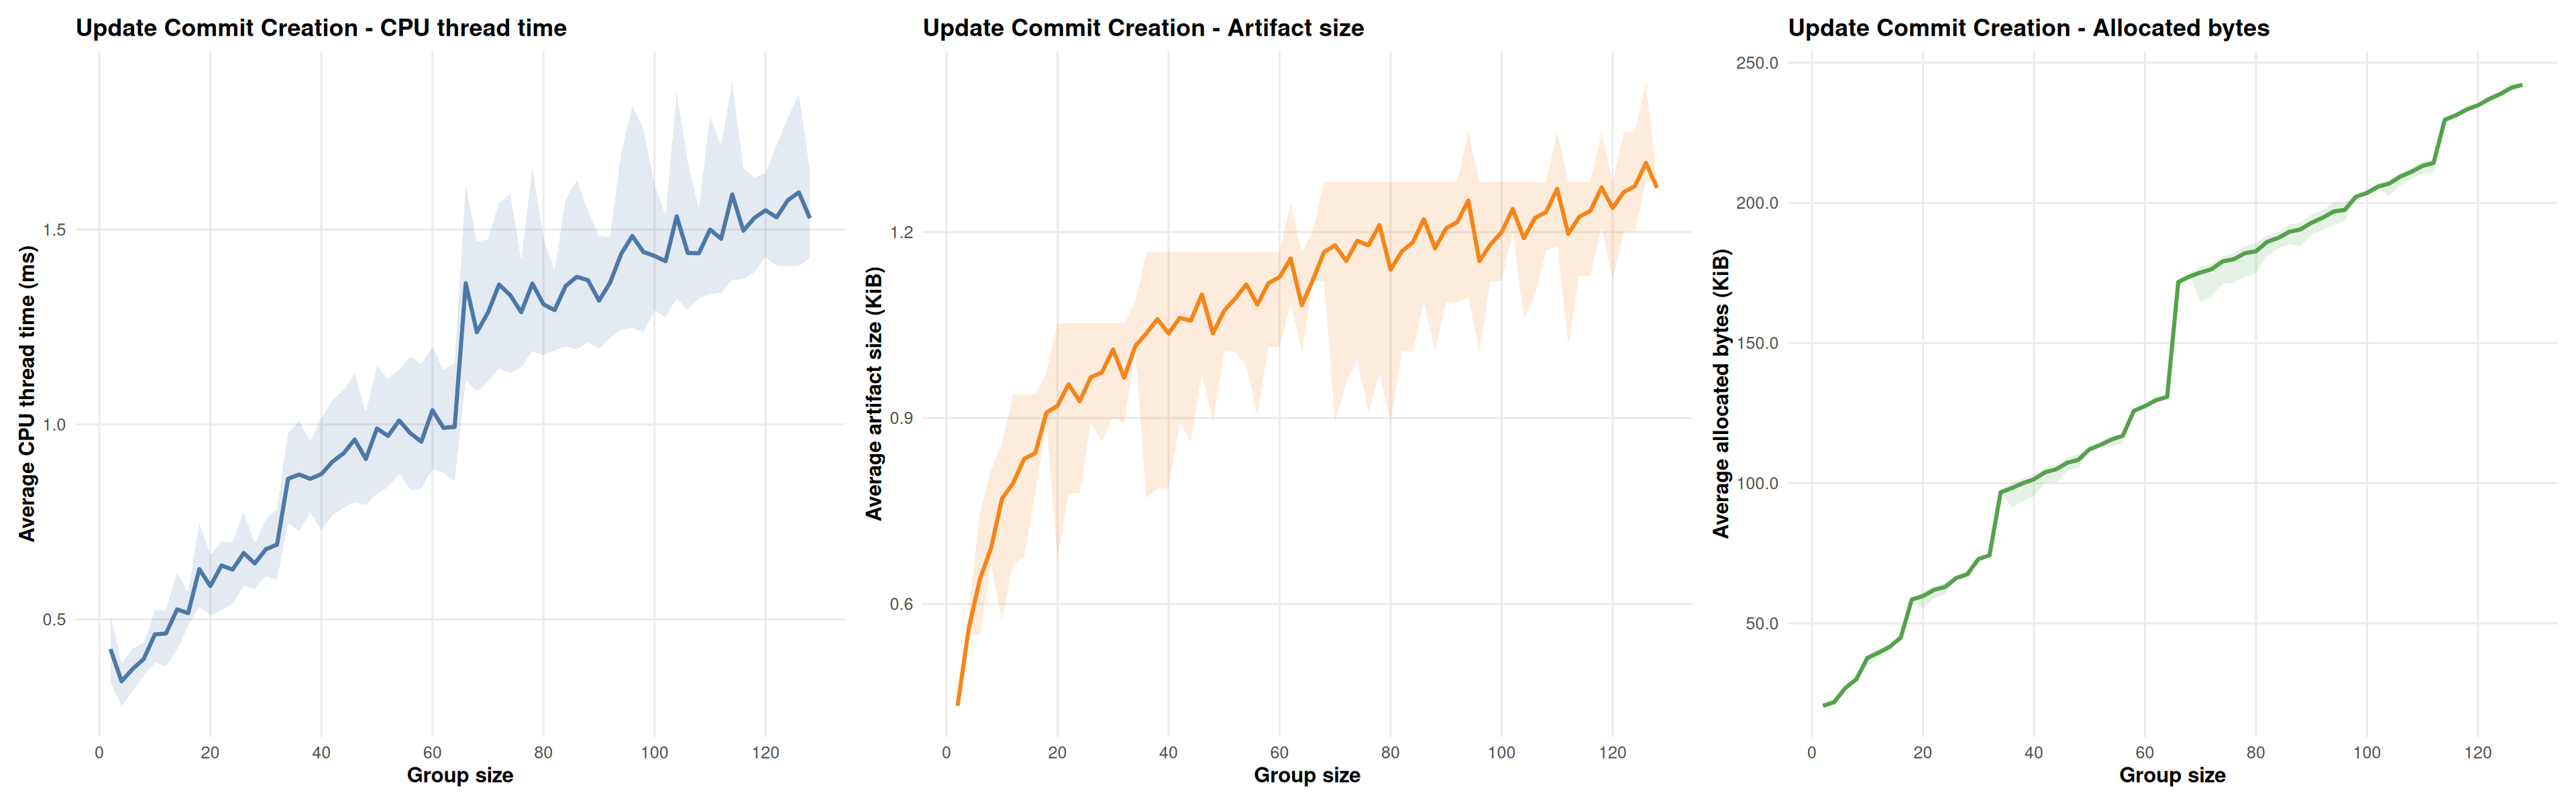

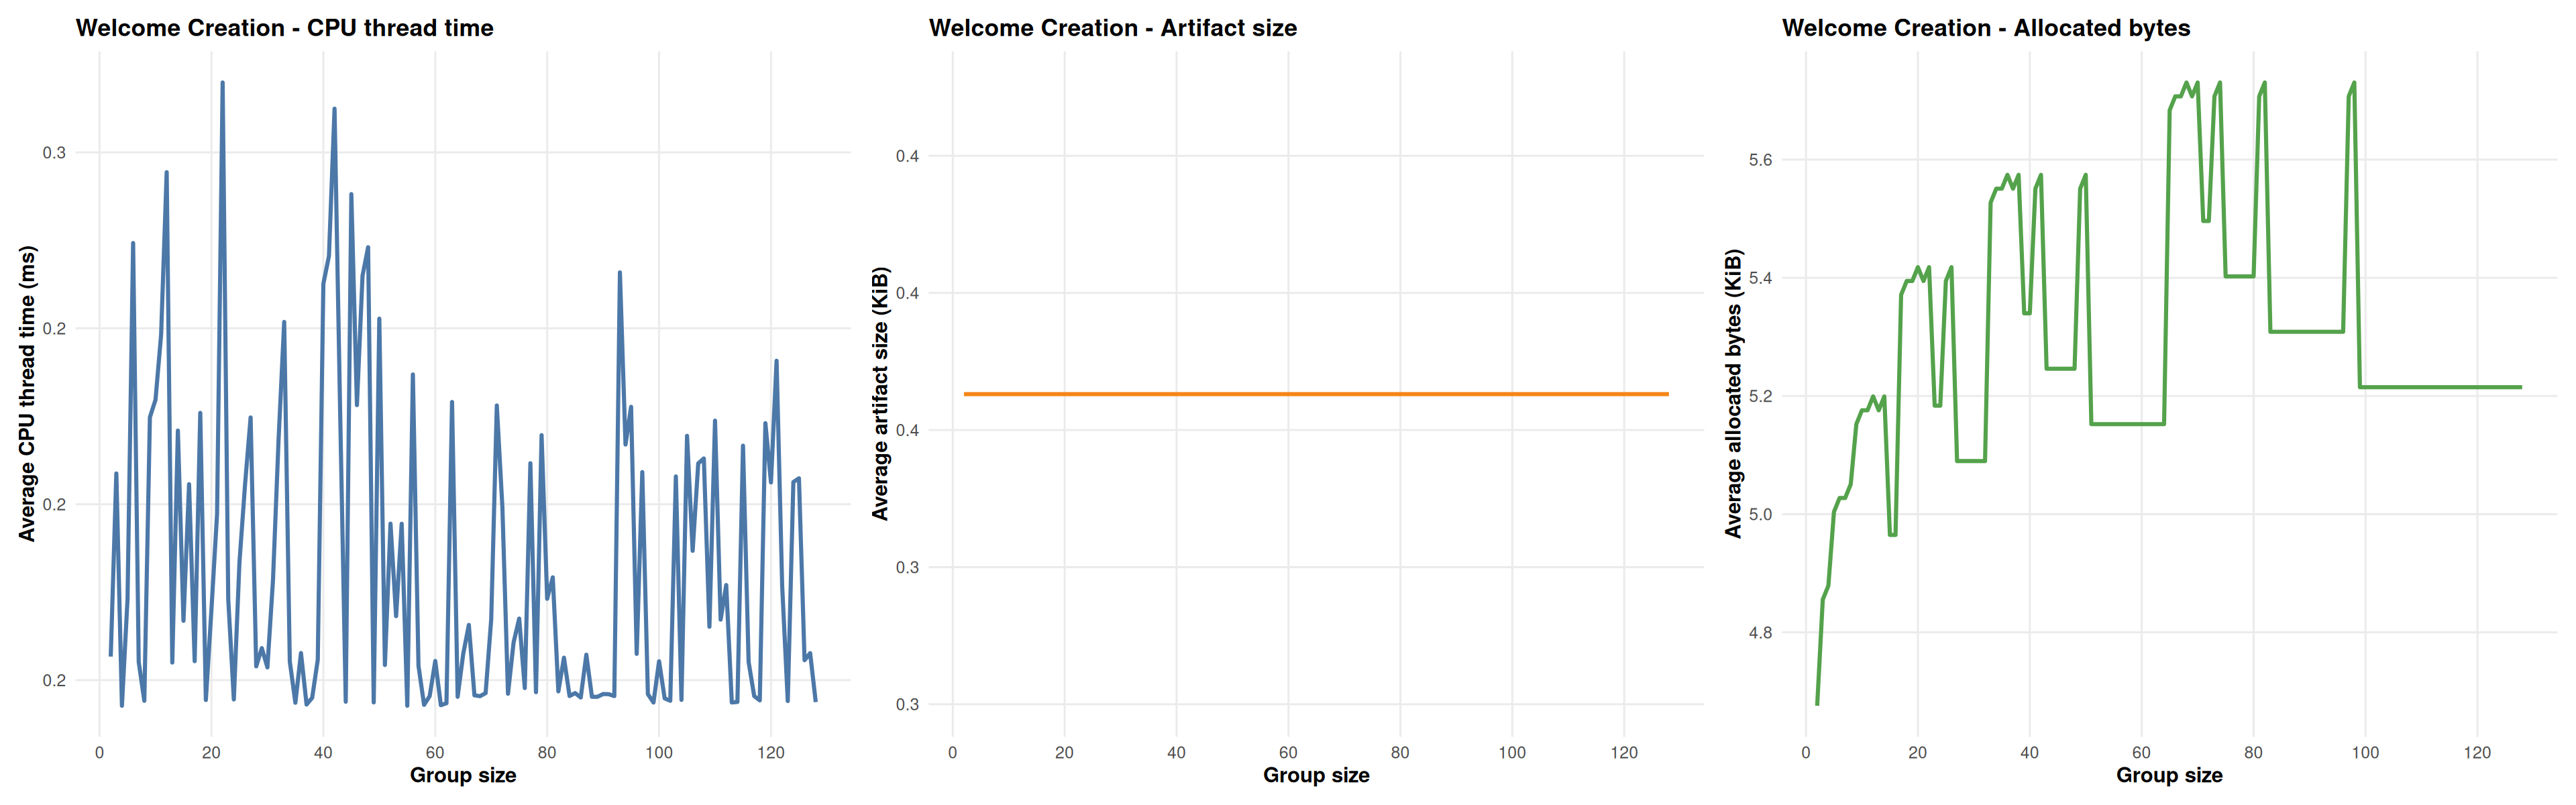

In [ ]:
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(scales)
  library(patchwork)
})

options(
  repr.plot.width = 24,
  repr.plot.height = 9,
  repr.plot.res = 160,
  tibble.width = Inf
)

# ============================================================
# 1. Load every events.csv we can find
# ============================================================

csv_paths <- character()

if (dir.exists("benchmark_output")) {
  csv_paths <- list.files(
    "benchmark_output",
    pattern = "^events\\.csv$",
    recursive = TRUE,
    full.names = TRUE
  )
}

csv_paths <- unique(c(
  csv_paths,
  if (file.exists("events.csv")) "events.csv" else character(),
  if (file.exists("/mnt/data/events.csv")) "/mnt/data/events.csv" else character()
))

csv_paths <- csv_paths[file.exists(csv_paths)]

if (length(csv_paths) == 0) {
  stop("No events.csv found. Put events.csv in the notebook directory or run this from the repository root.")
}

df_raw <- bind_rows(lapply(csv_paths, function(path) {
  read_csv(
    path,
    show_col_types = FALSE,
    col_types = cols(
      .default = col_guess(),
      worker_id = col_character(),
      ts_unix_ns = col_character(),
      thread_id = col_character(),
      run_id = col_character(),
      scenario = col_character(),
      node_name = col_character(),
      pod_name = col_character()
    )
  ) %>%
    mutate(
      source_file = path,
      source_run = basename(dirname(path))
    )
}))

num_cols <- c(
  "wall_ns",
  "cpu_thread_ns",
  "alloc_bytes",
  "alloc_count",
  "artifact_size_bytes",
  "encrypted_group_info_bytes",
  "encrypted_secrets_count",
  "group_epoch",
  "tree_size",
  "member_count",
  "invitee_count",
  "app_msg_plaintext_bytes",
  "app_msg_padding_bytes",
  "app_msg_ciphertext_bytes",
  "aad_bytes",
  "pid"
)

df <- df_raw %>%
  mutate(across(any_of(num_cols), ~ suppressWarnings(as.numeric(.x)))) %>%
  mutate(
    run_label = coalesce(na_if(run_id, ""), na_if(source_run, "."), source_file),
    .ts_num = suppressWarnings(as.numeric(ts_unix_ns)),

    op_label = recode(
      op,
      "add_commit_create" = "Add commit create",
      "update_commit_create" = "Update commit create",
      "remove_commit_create" = "Remove commit create",
      "welcome_create_total" = "Welcome create total",
      "application_message_create" = "Application message create",
      "application_message_receive" = "Application message receive",
      .default = op
    ),

    op_family = case_when(
      grepl("application_message", op) ~ "Application message",
      grepl("commit", op) ~ "Commit",
      grepl("welcome", op) ~ "Welcome",
      TRUE ~ "Other"
    ),

    member_count = as.integer(member_count),
    worker_num = suppressWarnings(as.integer(worker_id)),

    cpu_ms = cpu_thread_ns / 1e6,
    wall_ms = wall_ns / 1e6,
    alloc_kib = alloc_bytes / 1024,
    alloc_mib = alloc_bytes / 1024^2,
    artifact_kib = artifact_size_bytes / 1024,
    encrypted_group_info_kib = encrypted_group_info_bytes / 1024,

    app_plaintext_kib = app_msg_plaintext_bytes / 1024,
    app_ciphertext_kib = app_msg_ciphertext_bytes / 1024,
    app_overhead_bytes = app_msg_ciphertext_bytes - app_msg_plaintext_bytes,
    app_overhead_kib = app_overhead_bytes / 1024,
    app_expansion = app_msg_ciphertext_bytes / pmax(app_msg_plaintext_bytes, 1),

    wall_cpu_ratio = wall_ms / pmax(cpu_ms, .Machine$double.eps),

    payload_label = ifelse(
      is.na(app_msg_plaintext_bytes),
      "not app",
      paste0(comma(app_msg_plaintext_bytes), " B")
    )
  ) %>%
  group_by(run_label) %>%
  arrange(.ts_num, .by_group = TRUE) %>%
  mutate(event_index = row_number()) %>%
  ungroup()

op_order <- c(
  "Add commit create",
  "Update commit create",
  "Remove commit create",
  "Welcome create total",
  "Application message create",
  "Application message receive"
)

op_levels <- unique(c(op_order, sort(setdiff(unique(df$op_label), op_order))))
df <- df %>% mutate(op_label = factor(op_label, levels = op_levels))

# ============================================================
# 2. Small helpers
# ============================================================

qv <- function(x, p) {
  x <- x[is.finite(x)]
  if (length(x) == 0) return(NA_real_)
  as.numeric(quantile(x, p, na.rm = TRUE, names = FALSE))
}

min_na <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_real_)
  min(x)
}

max_na <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_real_)
  max(x)
}

safe_cor <- function(x, y) {
  x <- as.numeric(x)
  y <- as.numeric(y)
  ok <- is.finite(x) & is.finite(y)

  if (sum(ok) < 3) return(NA_real_)
  if (length(unique(x[ok])) < 2) return(NA_real_)
  if (length(unique(y[ok])) < 2) return(NA_real_)

  suppressWarnings(cor(x[ok], y[ok], method = "spearman"))
}

theme_bench <- function(base_size = 13) {
  theme_minimal(base_size = base_size) +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_line(linewidth = 0.15),
      panel.grid.major.y = element_line(linewidth = 0.20),
      plot.title = element_text(face = "bold", size = base_size + 5),
      plot.subtitle = element_text(size = base_size - 1),
      axis.title = element_text(face = "bold"),
      strip.text = element_text(face = "bold", size = base_size),
      legend.position = "bottom",
      legend.title = element_text(face = "bold")
    )
}

metric_member_summary <- function(metric) {
  df %>%
    filter(is.finite(.data[[metric]]), is.finite(member_count)) %>%
    group_by(run_label, op_label, member_count) %>%
    summarise(
      n = n(),
      median = median(.data[[metric]], na.rm = TRUE),
      q10 = qv(.data[[metric]], 0.10),
      q90 = qv(.data[[metric]], 0.90),
      .groups = "drop"
    )
}

plot_member_metric <- function(metric, ylab, title, subtitle = NULL, accuracy = 0.1) {
  s <- metric_member_summary(metric)

  if (nrow(s) == 0) {
    return(
      ggplot() +
        theme_void() +
        labs(title = paste("No data for", metric))
    )
  }

  p <- ggplot(
    s,
    aes(
      x = member_count,
      y = median,
      color = run_label,
      fill = run_label,
      group = run_label
    )
  ) +
    geom_ribbon(aes(ymin = q10, ymax = q90), alpha = 0.14, color = NA) +
    geom_line(linewidth = 1.05) +
    geom_point(aes(size = n), alpha = 0.55) +
    facet_wrap(~ op_label, scales = "free_y", ncol = 3) +
    scale_x_continuous(breaks = pretty_breaks(n = 10)) +
    scale_y_continuous(labels = label_number(accuracy = accuracy)) +
    guides(size = "none") +
    labs(
      title = title,
      subtitle = subtitle,
      x = "Group size / member_count",
      y = ylab,
      color = "Run",
      fill = "Run"
    ) +
    theme_bench()

  if (n_distinct(s$run_label) == 1) {
    p <- p + guides(color = "none", fill = "none")
  }

  p
}

# ============================================================
# 3. Text summaries: inspect these before trusting plots
# ============================================================

cat("\nLoaded files:\n")
print(tibble(events_csv = csv_paths), n = Inf)

cat("\nRows per run and operation:\n")
op_counts <- df %>%
  count(run_label, op_label, name = "events") %>%
  arrange(run_label, op_label)

print(op_counts, n = Inf)

plausibility_table <- df %>%
  group_by(run_label, op_label) %>%
  summarise(
    events = n(),
    workers_seen = n_distinct(worker_id),
    member_min = min_na(member_count),
    member_max = max_na(member_count),
    payloads_bytes = {
      x <- sort(unique(na.omit(app_msg_plaintext_bytes)))
      if (length(x) == 0) "—" else paste(x, collapse = ", ")
    },
    cpu_ms_median = median(cpu_ms, na.rm = TRUE),
    cpu_ms_p90 = qv(cpu_ms, 0.90),
    cpu_ms_max = max_na(cpu_ms),
    wall_ms_median = median(wall_ms, na.rm = TRUE),
    wall_cpu_ratio_median = median(wall_cpu_ratio, na.rm = TRUE),
    alloc_kib_median = median(alloc_kib, na.rm = TRUE),
    alloc_kib_p90 = qv(alloc_kib, 0.90),
    artifact_kib_median = median(artifact_kib, na.rm = TRUE),
    artifact_kib_p90 = qv(artifact_kib, 0.90),
    artifact_kib_max = max_na(artifact_kib),
    .groups = "drop"
  ) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

cat("\nPlausibility summary by operation:\n")
print(plausibility_table, n = Inf)

trend_table <- df %>%
  group_by(run_label, op_label) %>%
  summarise(
    events = n(),
    cor_member_cpu = safe_cor(member_count, cpu_ms),
    cor_member_wall = safe_cor(member_count, wall_ms),
    cor_member_alloc = safe_cor(member_count, alloc_kib),
    cor_member_artifact = safe_cor(member_count, artifact_kib),
    cor_payload_cpu = safe_cor(app_msg_plaintext_bytes, cpu_ms),
    cor_payload_ciphertext = safe_cor(app_msg_plaintext_bytes, app_msg_ciphertext_bytes),
    .groups = "drop"
  ) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

cat("\nSpearman trend sanity checks:\n")
print(trend_table, n = Inf)

outlier_table <- df %>%
  group_by(run_label, op_label) %>%
  mutate(
    op_cpu_median = median(cpu_ms, na.rm = TRUE),
    op_cpu_mad = mad(cpu_ms, na.rm = TRUE),
    robust_cpu_z = if_else(
      is.finite(op_cpu_mad) & op_cpu_mad > 0,
      abs(cpu_ms - op_cpu_median) / (1.4826 * op_cpu_mad),
      NA_real_
    )
  ) %>%
  ungroup() %>%
  arrange(desc(robust_cpu_z), desc(cpu_ms)) %>%
  select(
    run_label,
    op,
    worker_id,
    member_count,
    group_epoch,
    app_msg_plaintext_bytes,
    cpu_ms,
    wall_ms,
    wall_cpu_ratio,
    alloc_kib,
    artifact_kib,
    robust_cpu_z
  ) %>%
  slice_head(n = 25) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

cat("\nTop CPU outliers by robust z-score:\n")
print(outlier_table, n = 25)

# ============================================================
# 4. Coverage plots: are there enough samples?
# ============================================================

p_counts <- op_counts %>%
  ggplot(aes(x = reorder(op_label, events), y = events, fill = op_label)) +
  geom_col(show.legend = FALSE, width = 0.72) +
  coord_flip() +
  facet_wrap(~ run_label, scales = "free_x") +
  scale_y_continuous(labels = label_comma()) +
  labs(
    title = "Event counts by operation",
    subtitle = "First check: operations with few rows should not be overinterpreted.",
    x = NULL,
    y = "Events"
  ) +
  theme_bench()

p_coverage <- df %>%
  count(run_label, op_label, member_count, name = "events") %>%
  ggplot(aes(x = member_count, y = events, fill = op_label)) +
  geom_col(width = 0.9, show.legend = FALSE) +
  facet_wrap(~ op_label, scales = "free_y", ncol = 3) +
  scale_x_continuous(breaks = pretty_breaks(n = 10)) +
  scale_y_continuous(labels = label_comma()) +
  labs(
    title = "Sample coverage across group sizes",
    subtitle = "This reveals staircase plateaus, caps, endpoints, and single-sample transition rows.",
    x = "Group size / member_count",
    y = "Events"
  ) +
  theme_bench()

print((p_counts / p_coverage) + plot_layout(heights = c(1, 1.3)))

# ============================================================
# 5. Broad metric suite: CPU, wall time, allocation, artifact size
# ============================================================

print(plot_member_metric(
  "cpu_ms",
  "Median CPU thread time (ms)",
  "CPU thread time by operation and group size",
  "Line = median; ribbon = 10th–90th percentile; point size = sample count.",
  accuracy = 0.01
))

print(plot_member_metric(
  "wall_ms",
  "Median wall-clock time (ms)",
  "Wall-clock time by operation and group size",
  "Large wall-vs-CPU gaps can indicate scheduling, IO, locking, or container noise.",
  accuracy = 0.01
))

print(plot_member_metric(
  "alloc_kib",
  "Median allocated memory (KiB)",
  "Allocated bytes by operation and group size",
  "This is often the clearest signal when CPU timings are noisy.",
  accuracy = 1
))

print(plot_member_metric(
  "artifact_kib",
  "Median artifact size (KiB)",
  "Serialized artifact size by operation and group size",
  "For application-message creation this should mostly track ciphertext/message size; for commits it should reflect commit serialization.",
  accuracy = 0.01
))

# ============================================================
# 6. Distribution and timing-noise checks
# ============================================================

p_cpu_dist <- df %>%
  filter(is.finite(cpu_ms), cpu_ms > 0) %>%
  ggplot(aes(x = op_label, y = cpu_ms, fill = op_label)) +
  geom_violin(scale = "width", alpha = 0.24, color = NA, show.legend = FALSE) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.18, show.legend = FALSE) +
  coord_flip() +
  scale_y_log10(labels = label_number(accuracy = 0.01)) +
  labs(
    title = "CPU-time distribution, log scale",
    subtitle = "Good for spotting heavy tails, multimodality, and isolated anomalies.",
    x = NULL,
    y = "CPU thread time (ms, log10)"
  ) +
  theme_bench()

p_ratio_dist <- df %>%
  filter(is.finite(wall_cpu_ratio), wall_cpu_ratio > 0) %>%
  ggplot(aes(x = op_label, y = wall_cpu_ratio, fill = op_label)) +
  geom_violin(scale = "width", alpha = 0.24, color = NA, show.legend = FALSE) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.18, show.legend = FALSE) +
  coord_flip() +
  scale_y_log10(labels = label_number(accuracy = 0.1)) +
  labs(
    title = "Wall / CPU ratio, log scale",
    subtitle = "Near 1 means mostly CPU-bound; high values suggest waiting, scheduling, network, or relay/DS effects.",
    x = NULL,
    y = "wall_ms / cpu_ms"
  ) +
  theme_bench()

print(p_cpu_dist | p_ratio_dist)

p_wall_cpu <- df %>%
  filter(is.finite(cpu_ms), is.finite(wall_ms), cpu_ms > 0, wall_ms > 0) %>%
  ggplot(aes(x = cpu_ms, y = wall_ms, color = op_label)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", linewidth = 0.5) +
  geom_point(alpha = 0.22, size = 0.9, show.legend = FALSE) +
  facet_wrap(~ op_label, scales = "free", ncol = 3) +
  scale_x_log10(labels = label_number(accuracy = 0.01)) +
  scale_y_log10(labels = label_number(accuracy = 0.01)) +
  labs(
    title = "Wall time vs CPU thread time",
    subtitle = "The dashed line is wall = CPU. Points far above it are not pure cryptographic compute.",
    x = "CPU thread time (ms, log10)",
    y = "Wall-clock time (ms, log10)"
  ) +
  theme_bench()

print(p_wall_cpu)

p_timeline <- df %>%
  filter(is.finite(cpu_ms), cpu_ms > 0) %>%
  ggplot(aes(x = event_index, y = cpu_ms, color = op_label)) +
  geom_point(alpha = 0.24, size = 0.8) +
  facet_wrap(~ run_label, scales = "free_x") +
  scale_y_log10(labels = label_number(accuracy = 0.01)) +
  labs(
    title = "CPU time over event sequence",
    subtitle = "Useful for spotting warmup effects, phase changes, late-run drift, or one bad plateau.",
    x = "Event index within run",
    y = "CPU thread time (ms, log10)",
    color = "Operation"
  ) +
  theme_bench()

print(p_timeline)

# ============================================================
# 7. Commit-focused dashboard
# ============================================================

commit_ops <- c(
  "add_commit_create",
  "update_commit_create",
  "remove_commit_create",
  "welcome_create_total"
)

commit_metrics <- c(
  "cpu_ms",
  "wall_ms",
  "alloc_kib",
  "artifact_kib",
  "encrypted_group_info_kib",
  "encrypted_secrets_count"
)

commit_long <- df %>%
  filter(op %in% commit_ops) %>%
  select(run_label, op_label, member_count, any_of(commit_metrics)) %>%
  pivot_longer(
    cols = any_of(commit_metrics),
    names_to = "metric",
    values_to = "value"
  ) %>%
  filter(is.finite(value)) %>%
  group_by(run_label, op_label, member_count, metric) %>%
  summarise(
    n = n(),
    median = median(value, na.rm = TRUE),
    q10 = qv(value, 0.10),
    q90 = qv(value, 0.90),
    .groups = "drop"
  ) %>%
  mutate(
    metric_label = recode(
      metric,
      "cpu_ms" = "CPU ms",
      "wall_ms" = "Wall ms",
      "alloc_kib" = "Alloc KiB",
      "artifact_kib" = "Artifact KiB",
      "encrypted_group_info_kib" = "Encrypted GroupInfo KiB",
      "encrypted_secrets_count" = "Encrypted secrets count",
      .default = metric
    )
  )

if (nrow(commit_long) > 0) {
  p_commit_dashboard <- ggplot(
    commit_long,
    aes(
      x = member_count,
      y = median,
      color = run_label,
      fill = run_label,
      group = run_label
    )
  ) +
    geom_ribbon(aes(ymin = q10, ymax = q90), alpha = 0.12, color = NA) +
    geom_line(linewidth = 0.95) +
    geom_point(aes(size = n), alpha = 0.45) +
    facet_grid(metric_label ~ op_label, scales = "free_y") +
    scale_x_continuous(breaks = pretty_breaks(n = 8)) +
    scale_y_continuous(labels = label_number(accuracy = 0.01)) +
    guides(size = "none") +
    labs(
      title = "Commit and welcome dashboard",
      subtitle = "This is the main plausibility view for add/update/remove/welcome behavior.",
      x = "Group size / member_count",
      y = "Median value",
      color = "Run",
      fill = "Run"
    ) +
    theme_bench(base_size = 12)

  if (n_distinct(commit_long$run_label) == 1) {
    p_commit_dashboard <- p_commit_dashboard + guides(color = "none", fill = "none")
  }

  print(p_commit_dashboard)
}

# ============================================================
# 8. Application-message suite
# ============================================================

app_df <- df %>%
  filter(op %in% c("application_message_create", "application_message_receive"))

if (nrow(app_df) > 0) {
  app_sum <- app_df %>%
    filter(is.finite(app_msg_plaintext_bytes)) %>%
    group_by(run_label, op_label, member_count, app_msg_plaintext_bytes, payload_label) %>%
    summarise(
      n = n(),
      cpu_median = median(cpu_ms, na.rm = TRUE),
      cpu_q10 = qv(cpu_ms, 0.10),
      cpu_q90 = qv(cpu_ms, 0.90),
      wall_median = median(wall_ms, na.rm = TRUE),
      alloc_median = median(alloc_kib, na.rm = TRUE),
      artifact_median = median(artifact_kib, na.rm = TRUE),
      ciphertext_median = median(app_ciphertext_kib, na.rm = TRUE),
      overhead_median = median(app_overhead_kib, na.rm = TRUE),
      expansion_median = median(app_expansion, na.rm = TRUE),
      .groups = "drop"
    )

  p_app_cpu <- ggplot(
    app_sum,
    aes(
      x = member_count,
      y = cpu_median,
      color = payload_label,
      fill = payload_label,
      group = interaction(run_label, payload_label)
    )
  ) +
    geom_ribbon(aes(ymin = cpu_q10, ymax = cpu_q90), alpha = 0.11, color = NA) +
    geom_line(linewidth = 1.05) +
    geom_point(aes(size = n), alpha = 0.50) +
    facet_wrap(~ op_label, scales = "free_y", ncol = 2) +
    scale_x_continuous(breaks = pretty_breaks(n = 10)) +
    scale_y_continuous(labels = label_number(accuracy = 0.01)) +
    guides(size = "none") +
    labs(
      title = "Application-message CPU by payload size",
      subtitle = "Create and receive are separated. If payload size barely changes CPU, crypto/tree processing dominates payload copying.",
      x = "Group size / member_count",
      y = "Median CPU thread time (ms)",
      color = "Payload",
      fill = "Payload"
    ) +
    theme_bench()

  print(p_app_cpu)

  app_size_long <- app_df %>%
    filter(op == "application_message_create", is.finite(app_msg_plaintext_bytes)) %>%
    mutate(
      plaintext_kib = app_msg_plaintext_bytes / 1024,
      ciphertext_kib = app_msg_ciphertext_bytes / 1024,
      overhead_kib = app_overhead_bytes / 1024
    ) %>%
    select(
      run_label,
      member_count,
      app_msg_plaintext_bytes,
      payload_label,
      plaintext_kib,
      ciphertext_kib,
      artifact_kib,
      overhead_kib,
      app_expansion
    ) %>%
    pivot_longer(
      cols = c(plaintext_kib, ciphertext_kib, artifact_kib, overhead_kib, app_expansion),
      names_to = "metric",
      values_to = "value"
    ) %>%
    filter(is.finite(value)) %>%
    mutate(
      metric_label = recode(
        metric,
        "plaintext_kib" = "Plaintext KiB",
        "ciphertext_kib" = "Ciphertext KiB",
        "artifact_kib" = "Artifact KiB",
        "overhead_kib" = "Ciphertext - plaintext KiB",
        "app_expansion" = "Ciphertext / plaintext ratio",
        .default = metric
      )
    )

  if (nrow(app_size_long) > 0) {
    p_app_sizes <- ggplot(
      app_size_long,
      aes(x = payload_label, y = value, fill = payload_label)
    ) +
      geom_boxplot(outlier.alpha = 0.18, show.legend = FALSE) +
      facet_wrap(~ metric_label, scales = "free_y", ncol = 3) +
      labs(
        title = "Application-message size sanity checks",
        subtitle = "Ciphertext and artifact size should track plaintext payload size. Expansion ratio should be largest for tiny payloads.",
        x = "Plaintext payload",
        y = "Value"
      ) +
      theme_bench()

    print(p_app_sizes)
  }

  p_app_alloc <- ggplot(
    app_sum,
    aes(
      x = member_count,
      y = alloc_median,
      color = payload_label,
      group = interaction(run_label, payload_label)
    )
  ) +
    geom_line(linewidth = 1.05) +
    geom_point(aes(size = n), alpha = 0.50) +
    facet_wrap(~ op_label, scales = "free_y", ncol = 2) +
    scale_x_continuous(breaks = pretty_breaks(n = 10)) +
    scale_y_continuous(labels = label_number(accuracy = 1)) +
    guides(size = "none") +
    labs(
      title = "Application-message allocation by payload size",
      subtitle = "Useful for distinguishing payload-size effects from group-size effects.",
      x = "Group size / member_count",
      y = "Median allocated memory (KiB)",
      color = "Payload"
    ) +
    theme_bench()

  print(p_app_alloc)
}

# ============================================================
# 9. Worker coverage / sampling bias
# ============================================================

worker_plot_df <- df %>%
  filter(!is.na(worker_num)) %>%
  count(op_label, worker_num, name = "events")

if (nrow(worker_plot_df) > 0) {
  p_worker_coverage <- worker_plot_df %>%
    ggplot(aes(x = worker_num, y = events, fill = op_label)) +
    geom_col(width = 1, show.legend = FALSE) +
    facet_wrap(~ op_label, scales = "free_y", ncol = 3) +
    scale_x_continuous(breaks = pretty_breaks(n = 10)) +
    scale_y_continuous(labels = label_comma()) +
    labs(
      title = "Worker coverage by operation",
      subtitle = "Important for capped plateau sampling: if only low-numbered workers act often, CPU trends may reflect actor selection too.",
      x = "Worker number",
      y = "Events"
    ) +
    theme_bench()

  print(p_worker_coverage)
}

# ============================================================
# 10. Cross-metric relationships
# ============================================================

p_alloc_cpu <- df %>%
  filter(is.finite(cpu_ms), is.finite(alloc_kib), cpu_ms > 0, alloc_kib > 0) %>%
  ggplot(aes(x = alloc_kib, y = cpu_ms, color = op_label)) +
  geom_point(alpha = 0.22, size = 0.9, show.legend = FALSE) +
  facet_wrap(~ op_label, scales = "free", ncol = 3) +
  scale_x_log10(labels = label_number(accuracy = 1)) +
  scale_y_log10(labels = label_number(accuracy = 0.01)) +
  labs(
    title = "CPU time vs allocated memory",
    subtitle = "A strong diagonal relationship usually means allocations are a good proxy for computational work.",
    x = "Allocated memory (KiB, log10)",
    y = "CPU thread time (ms, log10)"
  ) +
  theme_bench()

print(p_alloc_cpu)

p_artifact_cpu <- df %>%
  filter(is.finite(cpu_ms), is.finite(artifact_kib), cpu_ms > 0, artifact_kib > 0) %>%
  ggplot(aes(x = artifact_kib, y = cpu_ms, color = op_label)) +
  geom_point(alpha = 0.24, size = 0.9, show.legend = FALSE) +
  facet_wrap(~ op_label, scales = "free", ncol = 3) +
  scale_x_log10(labels = label_number(accuracy = 0.01)) +
  scale_y_log10(labels = label_number(accuracy = 0.01)) +
  labs(
    title = "CPU time vs serialized artifact size",
    subtitle = "Helps separate 'large serialized output' effects from pure group-size effects.",
    x = "Artifact size (KiB, log10)",
    y = "CPU thread time (ms, log10)"
  ) +
  theme_bench()

print(p_artifact_cpu)

# Keep useful objects available in the notebook
invisible(list(
  df = df,
  op_counts = op_counts,
  plausibility_table = plausibility_table,
  trend_table = trend_table,
  outlier_table = outlier_table
))